## Imports, paths and raw vals

In [9]:
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
pd.set_option("display.max_columns", None)  # show all cols
pd.set_option("display.width", None)        # + better readability
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa
from itertools import combinations
import seaborn as sns
import re
from thefuzz import fuzz
from data_cleaner import *
import json
from matplotlib.ticker import MultipleLocator
from sklearn.metrics import accuracy_score, cohen_kappa_score

In [10]:
raw_path = RUNS_DATA_DIR / 'raw_responses'
csv_path = RUNS_DATA_DIR / 'responses'

In [11]:
cols_to_keep = [
    'model',
    'batch_index',
    'usage'
]

## Model Comparison

### Load and inspect data

In [12]:
files = sorted(raw_path.glob('20260917-*'))

dfs = []

for f in files:
    df_raw = pd.read_json(f, lines=True)[cols_to_keep]
    dfs.append(df_raw)

raw_df = pd.concat(dfs, ignore_index=True)
# unpack usage column
usage_df = pd.json_normalize(raw_df['usage'])
raw_df = pd.concat([raw_df.drop(columns='usage'), usage_df], axis=1)

raw_df.head()

,model,batch_index,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost,prompt_tokens_details.cache_creation_tokens
0,anthropic/claude-sonnet-5,0,6787,422164,428951,3342,1.132198,None,0,3342,None,None,0,0,0,0,0,None,0,0.912198,0.844328,0.06787,1.132198,0.844328,0.06787,0.0,0.0,0,0.22,None,None,None,NaN
1,anthropic/claude-sonnet-5,1,5477,528754,534231,1690,1.342278,None,0,1690,None,None,0,0,0,0,0,None,0,1.112278,1.057508,0.05477,1.342278,1.057508,0.05477,0.0,0.0,0,0.23,None,None,None,NaN
2,anthropic/claude-sonnet-5,2,9156,689256,698412,5519,1.710072,None,0,5519,None,None,0,0,0,0,0,None,0,1.470072,1.378512,0.09156,1.710072,1.378512,0.09156,0.0,0.0,0,0.24,None,None,None,NaN
3,anthropic/claude-sonnet-5,3,7346,500708,508054,3612,1.314876,None,0,3612,None,None,0,0,0,0,0,None,0,1.074876,1.001416,0.07346,1.314876,1.001416,0.07346,0.0,0.0,0,0.24,None,None,None,NaN
4,anthropic/claude-sonnet-5,4,9081,711779,720860,4953,1.804368,None,0,4953,None,None,0,0,0,0,0,None,0,1.514368,1.423558,0.09081,1.804368,1.423558,0.09081,0.0,0.0,0,0.29,None,None,None,NaN


In [13]:
sonnet_cache = pd.read_json(raw_path / '20260919-124908-claude-sonnet-5.jsonl', lines=True)[cols_to_keep]
sonnet_usage_df = pd.json_normalize(sonnet_cache['usage'])
sonnet_cache = pd.concat([sonnet_cache.drop(columns='usage'), sonnet_usage_df], axis=1)

sonnet_cache['model'] = sonnet_cache['model'].replace({ 'anthropic/claude-sonnet-5': 'anthropic/claude-sonnet-5-cached' }) # keep cached as own entry
raw_df = pd.concat([sonnet_cache, raw_df], axis=0)
raw_df

,model,batch_index,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,prompt_tokens_details.cache_creation_tokens,prompt_tokens_details.cache_creation.ephemeral_5m_input_tokens,prompt_tokens_details.cache_creation.ephemeral_1h_input_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost
0,anthropic/claude-sonnet-5-cached,0,3629,450116,453745,372,0.696806,None,0,372,None,None,0,0,156617,291227,0,None,0,156617.0,152494.0,4123.0,0.496806,0.460516,0.036290,0.696806,0.004544,0.036290,0.058245,0.397727,0,0.20,None,None,None
0,anthropic/claude-sonnet-5,0,6787,422164,428951,3342,1.132198,None,0,3342,None,None,0,0,0,0,0,None,0,NaN,NaN,NaN,0.912198,0.844328,0.067870,1.132198,0.844328,0.067870,0.000000,0.000000,0,0.22,None,None,None
1,anthropic/claude-sonnet-5,1,5477,528754,534231,1690,1.342278,None,0,1690,None,None,0,0,0,0,0,None,0,NaN,NaN,NaN,1.112278,1.057508,0.054770,1.342278,1.057508,0.054770,0.000000,0.000000,0,0.23,None,None,None
2,anthropic/claude-sonnet-5,2,9156,689256,698412,5519,1.710072,None,0,5519,None,None,0,0,0,0,0,None,0,NaN,NaN,NaN,1.470072,1.378512,0.091560,1.710072,1.378512,0.091560,0.000000,0.000000,0,0.24,None,None,None
3,anthropic/claude-sonnet-5,3,7346,500708,508054,3612,1.314876,None,0,3612,None,None,0,0,0,0,0,None,0,NaN,NaN,NaN,1.074876,1.001416,0.073460,1.314876,1.001416,0.073460,0.000000,0.000000,0,0.24,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,openai/gpt-5.6-terra,17,6185,107006,113191,4944,0.389510,None,0,4944,None,None,0,0,1369,5226,0,None,0,1369.0,NaN,NaN,0.279510,0.205290,0.074220,0.389510,0.200822,0.074220,0.001045,0.003422,0,0.11,None,None,None
84,openai/gpt-5.6-terra,18,4740,116565,121305,3512,0.431313,None,0,3512,None,None,0,0,1420,5226,0,None,0,1420.0,NaN,NaN,0.281313,0.224433,0.056880,0.431313,0.219838,0.056880,0.001045,0.003550,0,0.15,None,None,None
85,openai/gpt-5.6-terra,19,4705,87105,91810,3611,0.331970,None,0,3611,None,None,0,0,1414,5226,0,None,0,1414.0,NaN,NaN,0.221970,0.165510,0.056460,0.331970,0.160930,0.056460,0.001045,0.003535,0,0.11,None,None,None
86,openai/gpt-5.6-terra,20,4744,75949,80693,3591,0.280122,None,0,3591,None,None,0,0,1405,5226,0,None,0,1405.0,NaN,NaN,0.200122,0.143194,0.056928,0.280122,0.138636,0.056928,0.001045,0.003512,0,0.08,None,None,None


### Model Cost - 10% Sample Test

In [14]:
# gemini ran through two providers (google-vertex + google-ai-studio) -> strip the provider prefix so they're grouped together
raw_df['model_name'] = raw_df['model'].str.split('/').str[1]

# one row per batch call -> sum the cost of all batches per model
model_price = raw_df.groupby('model_name').agg(n_batches=('batch_index', 'nunique'), total_cost=('cost', 'sum'))
model_price.head()

,n_batches,total_cost
model_name,,
claude-sonnet-5,22,29.838944
claude-sonnet-5-cached,1,0.696806
gemini-3.7-flash,22,3.862064
gpt-5.6-luna,22,2.832598
gpt-5.6-terra,22,8.526132


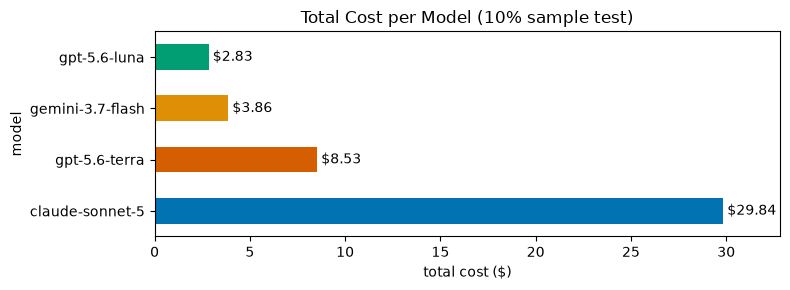

In [15]:
model_price_fairplot = model_price.drop(index='claude-sonnet-5-cached')
model_price_fairplot['estimated_full_cost'] = model_price_fairplot['total_cost'] * 10 # calculate estimated full price

# descending, since barh draws the first row at the bottom -> cheapest on top
plot_df = model_price_fairplot.sort_values('total_cost', ascending=False)
n_models = len(model_price_fairplot.index)
colors = sns.color_palette('colorblind', n_colors=n_models)
# tie each color to a model name (alphabetical, like the annotation plots) so sorting by cost doesn't reshuffle colors
model_colors = dict(zip(model_price_fairplot.index, colors))

ax = plot_df['total_cost'].plot(kind='barh', color=[model_colors[m] for m in plot_df.index], figsize=(8, 3))
ax.bar_label(ax.containers[0], fmt='$%.2f', padding=3)

ax.set_xlabel('total cost ($)')
ax.set_ylabel('model')
ax.set_title(f'Total Cost per Model (10% sample test)')
ax.margins(x=0.1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'total-cost-per-model-10%.svg')
plt.show()

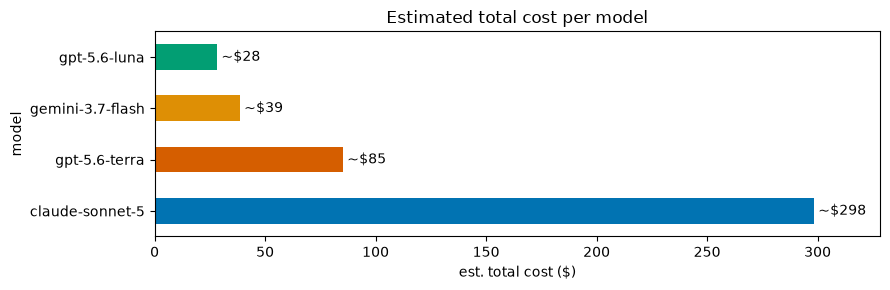

In [16]:
plot_df = model_price_fairplot.sort_values('estimated_full_cost', ascending=False)
n_models = len(model_price_fairplot.index)
colors = sns.color_palette('colorblind', n_colors=n_models)
# tie each color to a model name (alphabetical, like the annotation plots) so sorting by cost doesn't reshuffle colors
model_colors = dict(zip(model_price_fairplot.index, colors))

ax = plot_df['estimated_full_cost'].plot(kind='barh', color=[model_colors[m] for m in plot_df.index], figsize=(9, 3))
ax.bar_label(ax.containers[0], fmt='~$%.0f', padding=3)

ax.set_xlabel('est. total cost ($)')
ax.set_ylabel('model')
ax.set_title(f'Estimated total cost per model')
ax.margins(x=0.1)
plt.tight_layout()
plt.show()

### Model Tokens - 10% Sample Test

In [17]:
model_tokens = raw_df.groupby('model_name').agg(n_batches=('batch_index', 'nunique'), total_tokens=('total_tokens', 'sum'))
model_tokens = model_tokens.drop(index='claude-sonnet-5-cached')
model_tokens

,n_batches,total_tokens
model_name,,
claude-sonnet-5,22,11802600
gemini-3.7-flash,22,264219
gpt-5.6-luna,22,1944404
gpt-5.6-terra,22,2393997


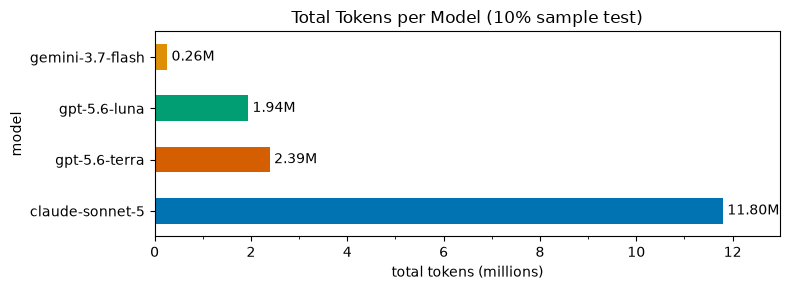

In [18]:
# descending, since barh draws the first row at the bottom -> fewest tokens on top
plot_df = model_tokens.sort_values('total_tokens', ascending=False)
n_models = len(model_tokens.index)
colors = sns.color_palette('colorblind', n_colors=n_models)
# tie each color to a model name (alphabetical, like the annotation plots) so sorting doesn't reshuffle colors
model_colors = dict(zip(model_tokens.index, colors))

# show in millions: keeps the linear scale (bar length = real ratio) but readable numbers
ax = (plot_df['total_tokens'] / 1e6).plot(kind='barh', color=[model_colors[m] for m in plot_df.index], figsize=(8, 3))
ax.bar_label(ax.containers[0], fmt='%.2fM', padding=3)

ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.set_xlabel('total tokens (millions)')
ax.set_ylabel('model')
ax.set_title(f'Total Tokens per Model (10% sample test)')
ax.margins(x=0.1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'total-tokens-pr-model-10%.svg')
plt.show()

### Sonnet Cached vs. Non Cached

In [19]:
sonnet_non_cached = pd.read_json(raw_path / '20260917-claude-sonnet-5.jsonl', lines=True)
sonnet_non_cached = sonnet_non_cached[sonnet_non_cached.batch_index == 0]
sonnet_non_cached = sonnet_non_cached[cols_to_keep]
usage_df = pd.json_normalize(sonnet_non_cached['usage'])
sonnet_non_cached = pd.concat([sonnet_non_cached.drop(columns='usage'), usage_df], axis=1)
sonnet_non_cached.head()

,model,batch_index,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost
0,anthropic/claude-sonnet-5,0,6787,422164,428951,3342,1.132198,None,0,3342,None,None,0,0,0,0,0,None,0,0.912198,0.844328,0.06787,1.132198,0.844328,0.06787,0,0,0,0.22,None,None,None


In [20]:
sonnet_cache = pd.read_json(raw_path / '20260919-124908-claude-sonnet-5.jsonl', lines=True)[cols_to_keep]
usage_df = pd.json_normalize(sonnet_cache['usage'])
sonnet_cache = pd.concat([sonnet_cache.drop(columns='usage'), usage_df], axis=1)
sonnet_cache

,model,batch_index,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,prompt_tokens_details.cache_creation_tokens,prompt_tokens_details.cache_creation.ephemeral_5m_input_tokens,prompt_tokens_details.cache_creation.ephemeral_1h_input_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost
0,anthropic/claude-sonnet-5,0,3629,450116,453745,372,0.696806,None,0,372,None,None,0,0,156617,291227,0,None,0,156617,152494,4123,0.496806,0.460516,0.03629,0.696806,0.004544,0.03629,0.058245,0.397727,0,0.2,None,None,None


In [21]:
df = pd.concat([sonnet_non_cached, sonnet_cache], keys=['non_cached', 'cached'], axis=0).droplevel(1)
df.dropna(axis='columns', how='all')

overall_cols = [
    'total_tokens', 
    'cost', #'cost_details.total_cost',     # these two are the same - use only one
    'cost_details.upstream_inference_cost',
    'prompt_tokens_details.cache_creation_tokens',
]

mapper1 = {
    'cost_details.upstream_inference_cost':'upstream_inference_cost',
    'prompt_tokens_details.cache_creation_tokens':'cache_creation_tokens',
}

detail_cols = [
    'completion_tokens',
    'prompt_tokens',
    'reasoning_tokens', # 'completions_tokens_details.reasoning_tokens', # these two are same - use only one 
    'prompt_tokens_details.cache_write_tokens',
    'prompt_tokens_details.cached_tokens',
    'cost_details.upstream_inference_prompt_cost',
    'cost_details.upstream_inference_completions_cost',
    'cost_details.input_cost',
    'cost_details.output_cost',
    'cost_details.cached_input_cost',
    'cost_details.cache_write_input_cost',
    'cost_details.web_search_cost',
    'prompt_tokens_details.cache_creation.ephemeral_5m_input_tokens',
    'prompt_tokens_details.cache_creation.ephemeral_1h_input_tokens'
]

mapper2 = {
    'prompt_tokens_details.cache_write_tokens':'cache_write_tokens',
    'prompt_tokens_details.cached_tokens':'cached_tokens',
    'cost_details.upstream_inference_prompt_cost':'upstream_inference_prompt_cost',
    'cost_details.upstream_inference_completions_cost':'upstream_inference_completions_cost',
    'cost_details.input_cost':'input_cost',
    'cost_details.output_cost':'output_cost',
    'cost_details.cached_input_cost':'cached_input_cost',
    'cost_details.cache_write_input_cost':'cache_write_input_cost',
    'cost_details.web_search_cost':'web_search_cost',
    'prompt_tokens_details.cache_creation.ephemeral_5m_input_tokens':'ephemeral_5m_input_tokens',
    'prompt_tokens_details.cache_creation.ephemeral_1h_input_tokens':'ephemeral_1h_input_tokens'
}

df_overall = df[overall_cols]
df_detailed = df[detail_cols]

df_overall = df_overall.rename(columns=mapper1)
df_detailed = df_detailed.rename(columns=mapper2)


In [22]:
df_detailed

,completion_tokens,prompt_tokens,reasoning_tokens,cache_write_tokens,cached_tokens,upstream_inference_prompt_cost,upstream_inference_completions_cost,input_cost,output_cost,cached_input_cost,cache_write_input_cost,web_search_cost,ephemeral_5m_input_tokens,ephemeral_1h_input_tokens
non_cached,6787,422164,3342,0,0,0.844328,0.06787,0.844328,0.06787,0.000000,0.000000,0.22,NaN,NaN
cached,3629,450116,372,156617,291227,0.460516,0.03629,0.004544,0.03629,0.058245,0.397727,0.20,152494.0,4123.0


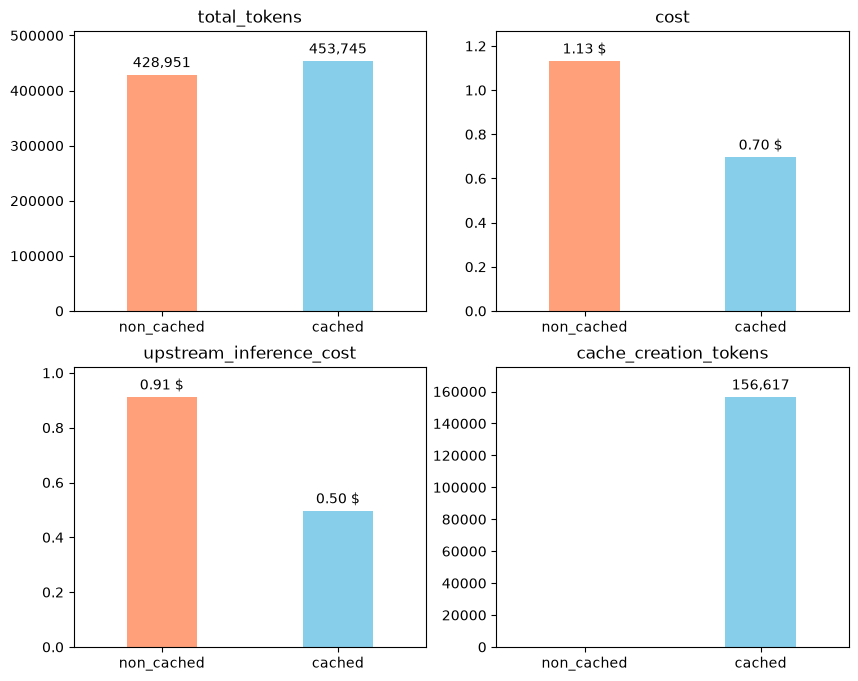

In [23]:
row_colors = {"non_cached": "lightsalmon", "cached": "skyblue"}

x = np.arange(len(df_overall.index))
labels = df_overall.index.astype(str)
colors = [row_colors[i] for i in df_overall.index]

def fmt(col, v):
    if pd.isna(v):
        return ""
    if "cost" in col.lower():
        return f"{v:,.2f} $"
    return f"{v:,.0f}"

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, df_overall.columns):
    bars = ax.bar(x, df_overall[col], width=0.4, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_title(col)
    ax.margins(y=0.12)
    ax.bar_label(bars, labels=[fmt(col, v) for v in df_overall[col]], padding=3)

handles = [mpatches.Patch(color=c, label=l) for l, c in row_colors.items()]
plt.show()


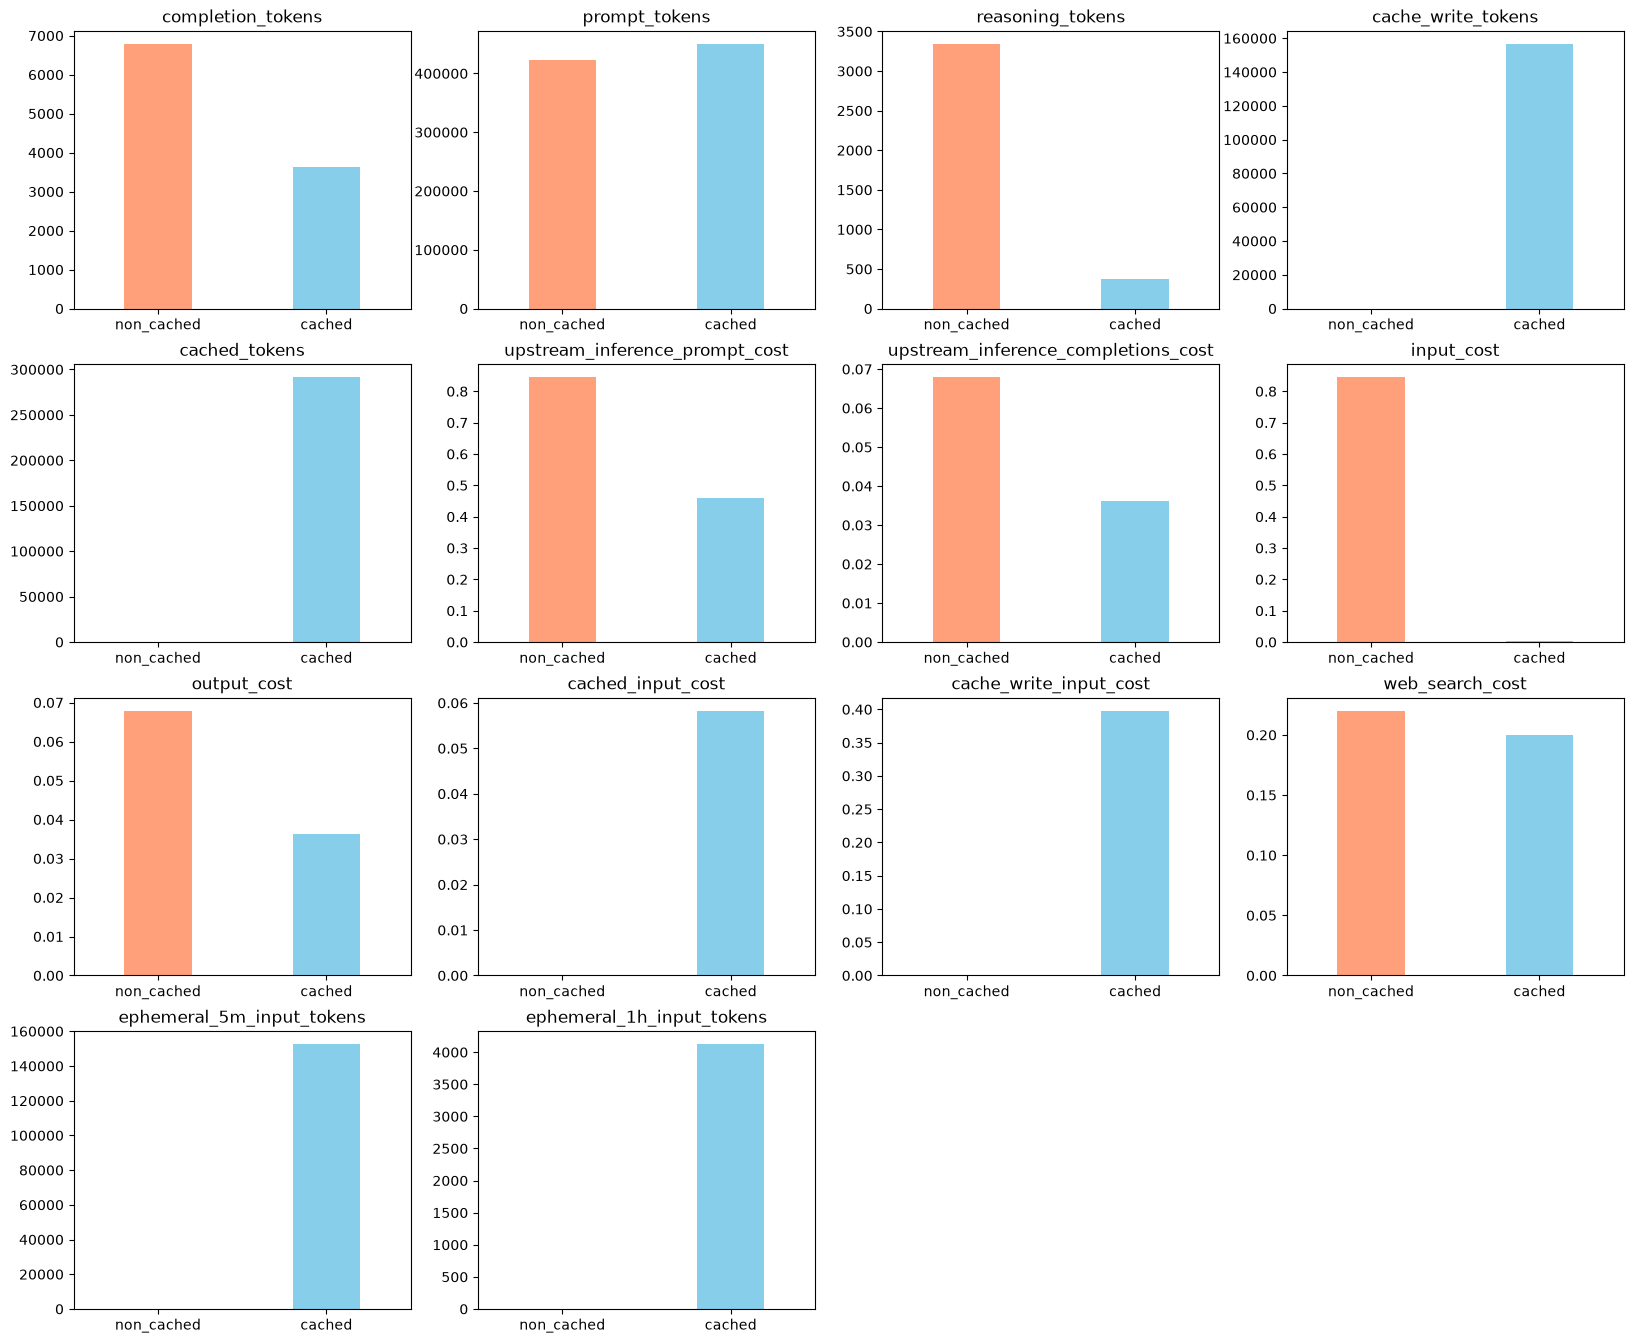

In [24]:
num_cols = df_detailed.columns
n = len(num_cols)
nrows = -(-n // 4)

x = np.arange(len(df_detailed.index))
labels = df_detailed.index.astype(str)
colors = [row_colors[i] for i in df_detailed.index]

fig, axes = plt.subplots(nrows, 4, figsize=(20, 4 * nrows + 0.6))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.bar(x, df_detailed[col], width=0.4, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_title(col)

for ax in axes[n:]:
    ax.axis("off")

handles = [mpatches.Patch(color=c, label=l) for l, c in row_colors.items()]
plt.show()


### Model Performance

In [25]:
cols_to_keep = [
    'model', 'batch_index', 'answer'
]

files = sorted(csv_path.glob('20260917-*'))

dfs = []
for f in files:
    df = pd.read_csv(f, usecols=cols_to_keep)
    df['answer'] = df['answer'].apply(json.loads)
    df_answer = pd.json_normalize(df['answer'])
    df = df.drop(columns=['answer']).join(df_answer)
    df['model'] = df['model'].str.split('/').str[1]
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df.head()

,model,batch_index,id,name,hasFoundMenu,menuLink,format,source
0,claude-sonnet-5,0,ChIJAV1_vX1SUkYRifHQGs0-33o,Pizze Di Napo Hellerup,True,https://pizzedinapohellerup.dk/,HTML,OFFICIAL_WEBSITE
1,claude-sonnet-5,0,ChIJ7RIaXXpQUkYRxGD3xBRRltk,McDonald's,True,https://www.mcdonalds.com/dk/da-dk/vores-menu....,HTML,OFFICIAL_WEBSITE
2,claude-sonnet-5,0,ChIJq6p-9w9TUkYRGJ7PByHSDYY,Byens Pizza,True,http://byens-pizza.dk/?page_id=2065,HTML,OFFICIAL_WEBSITE
3,claude-sonnet-5,0,ChIJz3lHpeRSUkYRRNH0_-MSMhU,Restaurant Taormina v/Mukuntharaj Karunaratnam,True,https://taormina.dk/menu/,HTML,OFFICIAL_WEBSITE
4,claude-sonnet-5,0,ChIJBVGBtQFTUkYR7R1FSqjW1kg,Barnetsfest,False,,,


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1756 entries, 0 to 1755
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   model         1756 non-null   object
 1   batch_index   1756 non-null   int64 
 2   id            1756 non-null   str   
 3   name          1756 non-null   str   
 4   hasFoundMenu  1756 non-null   bool  
 5   menuLink      1756 non-null   str   
 6   format        1756 non-null   str   
 7   source        1756 non-null   str   
dtypes: bool(1), int64(1), object(1), str(5)
memory usage: 97.9+ KB


In [27]:
grouped = df.groupby('model')['hasFoundMenu'].value_counts(normalize=True).reset_index(name='pct')
grouped.head()

,model,hasFoundMenu,pct
0,claude-sonnet-5,True,0.571754
1,claude-sonnet-5,False,0.428246
2,gemini-3.7-flash,True,0.740319
3,gemini-3.7-flash,False,0.259681
4,gpt-5.6-luna,True,0.640091


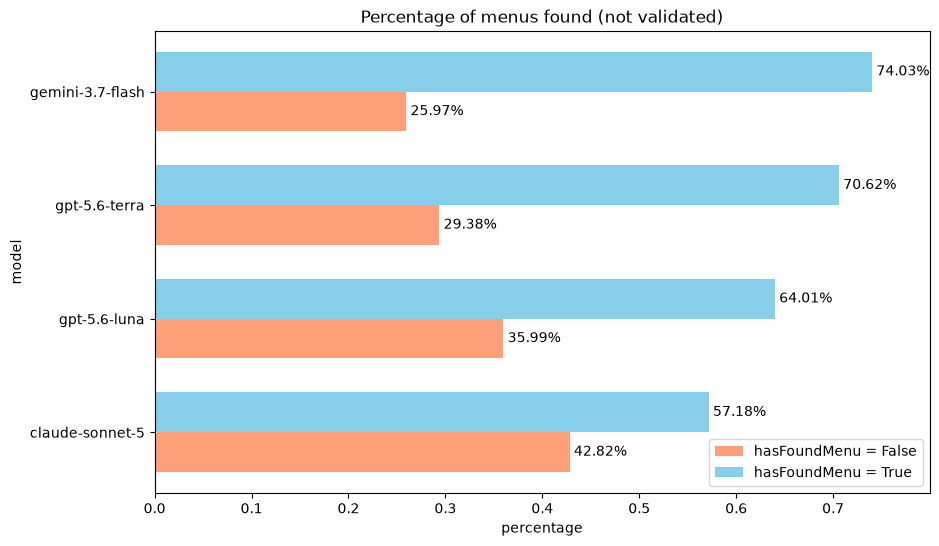

In [50]:
pivot = grouped.pivot(index='model', columns='hasFoundMenu', values='pct').sort_values(True)

models = pivot.index
y = np.arange(len(models))
height = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_false = ax.barh(y - height / 2, pivot[False], height=height, color='lightsalmon', label='hasFoundMenu = False')
bars_true = ax.barh(y + height / 2, pivot[True], height=height, color='skyblue', label='hasFoundMenu = True')

ax.bar_label(bars_true, fmt=lambda x: f'{x*100:.2f}%', padding=3)
ax.bar_label(bars_false, fmt=lambda x: f'{x*100:.2f}%', padding=3)

ax.set_yticks(y)
ax.set_yticklabels(models)
ax.set_xlabel('percentage')
ax.set_ylabel('model')
ax.set_title('Percentage of menus found (not validated)')
ax.margins(x=0.08)
ax.legend(loc='lower right')
# plt.tight_layout()
plt.savefig(PLOTS_DIR / 'menu-found-percentage-distribution-not-validated-10%.svg')
plt.show()


### Model Agreement on hasFoundMenu

In [29]:
pivot_found = df.pivot_table(index='id', columns='model', values='hasFoundMenu', aggfunc='first')
pivot_found

model,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
id,,,,
ChIJ-7iMbc1TUkYR066Hz1SQ-EI,True,True,True,True
ChIJ-QrW55VTUkYRiO5rYIpA5PE,True,True,True,True
ChIJ-XF3Wu1TUkYRl25fQ2IL8Ps,True,True,True,True
ChIJ-YewRThSUkYRU-ZX1KiCAr0,True,True,True,True
ChIJ-ao52_ZNUkYRU11OTne3ec8,True,True,True,True
...,...,...,...,...
ChIJzSGiCwVTUkYRM2XmxLIIRqc,True,True,True,True
ChIJzVHSkstTUkYRp1DtTvwjdlI,False,False,False,False
ChIJzX87fApZUkYR3MgmhXk4aXI,False,True,True,True


In [30]:
disagreement = pivot_found[pivot_found.nunique(axis=1) != 1]
print(f"Out of {len(pivot_found)} entries, at least one model disagrees on {len(disagreement)}")
disagreement.info()

Out of 439 entries, at least one model disagrees on 165
<class 'pandas.DataFrame'>
Index: 165 entries, ChIJ-xIoQDlTUkYRQYAPd7S0xRA to ChIJzX87fApZUkYR3MgmhXk4aXI
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   claude-sonnet-5   165 non-null    bool 
 1   gemini-3.7-flash  165 non-null    bool 
 2   gpt-5.6-luna      165 non-null    bool 
 3   gpt-5.6-terra     165 non-null    bool 
dtypes: bool(4)
memory usage: 1.9+ KB


In [31]:
strong_disagreement = pivot_found[pivot_found.sum(axis=1) == 2]
strong_disagreement.info()
strong_disagreement.head()

<class 'pandas.DataFrame'>
Index: 48 entries, ChIJ-xIoQDlTUkYRQYAPd7S0xRA to ChIJyfieJI5RUkYRC6iHiq8VzyM
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   claude-sonnet-5   48 non-null     bool 
 1   gemini-3.7-flash  48 non-null     bool 
 2   gpt-5.6-luna      48 non-null     bool 
 3   gpt-5.6-terra     48 non-null     bool 
dtypes: bool(4)
memory usage: 576.0+ bytes


model,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
id,,,,
ChIJ-xIoQDlTUkYRQYAPd7S0xRA,True,False,False,True
ChIJ1Xr-aQBTUkYR6a1iQdEuZXo,True,True,False,False
ChIJ2dkKoBdTUkYRC1QC_42BiLA,False,True,True,False
ChIJ33UBCxFTUkYRI9qpLDGK3Fo,False,True,False,True
ChIJ5-VhunhTUkYRegsb6Rn-TL4,False,True,False,True


In [32]:
table, categories = aggregate_raters(pivot_found.to_numpy())
kappa = fleiss_kappa(table)

print(f"Fleiss' kappa (hasFoundMenu, 4 raters): {kappa:.3f}")

Fleiss' kappa (hasFoundMenu, 4 raters): 0.538


#### Cohens Kappa - Pairwise Agreement

In [33]:
pivot_found.head()

model,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
id,,,,
ChIJ-7iMbc1TUkYR066Hz1SQ-EI,True,True,True,True
ChIJ-QrW55VTUkYRiO5rYIpA5PE,True,True,True,True
ChIJ-XF3Wu1TUkYRl25fQ2IL8Ps,True,True,True,True
ChIJ-YewRThSUkYRU-ZX1KiCAr0,True,True,True,True
ChIJ-ao52_ZNUkYRU11OTne3ec8,True,True,True,True


In [61]:
corr = pivot_found.corr()
corr

model,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
model,,,,
claude-sonnet-5,1.000000,0.526847,0.482787,0.482618
gemini-3.7-flash,0.526847,1.000000,0.573353,0.655800
gpt-5.6-luna,0.482787,0.573353,1.000000,0.631070
gpt-5.6-terra,0.482618,0.655800,0.631070,1.000000


Note: the plot says nothing about the URLs, just where they both found a menu link


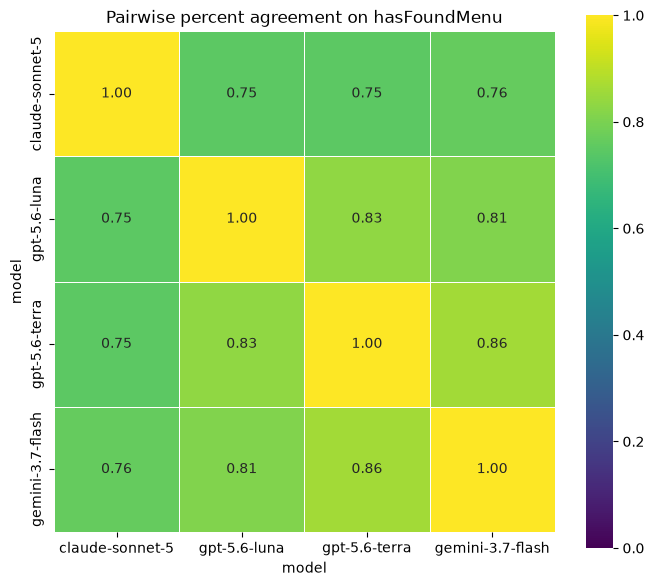

In [55]:
agreement = pd.DataFrame(np.eye(len(models)), index=models, columns=models)

for model_1, model_2 in combinations(models, 2):
    rate = (pivot_found[model_1] == pivot_found[model_2]).mean()
    agreement.loc[model_1, model_2] = rate
    agreement.loc[model_2, model_1] = rate

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(agreement, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='viridis', square=True, ax=ax, linewidths=0.5)
ax.set_title('Pairwise percent agreement on hasFoundMenu')
plt.tight_layout()
print(f"Note: the plot says nothing about the URLs, just where they both found a menu link")
plt.show()

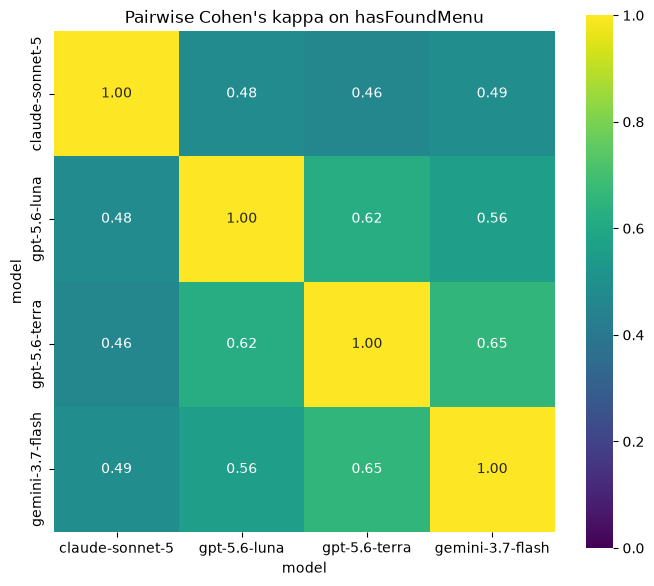

In [35]:
kappa = pd.DataFrame(np.eye(len(models)), index=models, columns=models)

for model_1, model_2 in combinations(models, 2):
    k = cohen_kappa_score(pivot_found[model_1], pivot_found[model_2])
    kappa.loc[model_1, model_2] = k
    kappa.loc[model_2, model_1] = k

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(kappa, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='viridis', square=True, ax=ax)
ax.set_title("Pairwise Cohen's kappa on hasFoundMenu")
plt.tight_layout()
plt.show()


#### Coincidence Matrix - Cohens Kappa on GPT models

In [36]:
coincidence_matrix = pd.crosstab(pivot_found['gpt-5.6-luna'], pivot_found['gpt-5.6-terra'])
coincidence_matrix

gpt-5.6-terra,False,True
gpt-5.6-luna,,
False,107,51
True,22,259


### Model Agreement on menuLinks after cleaning URLs

- Ignoring prefix such as `http`, `https://`, `www.` etc.
- Suffix `/`

In [37]:
url_prefix_pattern = re.compile(r'^(?:https?://)?(?:www\.)?', re.IGNORECASE)

df['normalized_urls'] = df['menuLink'].str.replace(url_prefix_pattern, '', regex=True)
df['normalized_urls'] = df['normalized_urls'].str.rstrip('/')
df_menulinks = df.pivot_table(index='id', columns='model', values='normalized_urls', aggfunc='first')
df_menulinks.head()

model,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
id,,,,
ChIJ-7iMbc1TUkYR066Hz1SQ-EI,restaurantalf.dk,restaurantalf.dk,restaurantalf.dk,restaurantalf.dk
ChIJ-QrW55VTUkYRiO5rYIpA5PE,durumbar-frb.dk,durumbar78.dk,durumbar2000.dk,ubereats.com/dk-en/store/durum-bar-2000/KBI4og...
ChIJ-XF3Wu1TUkYRl25fQ2IL8Ps,royalbagel.dk/royal-bagel-valby-langgade/takeaway,wolt.com/da/dnk/copenhagen/restaurant/royal-ba...,wolt.com/da/dnk/copenhagen/restaurant/royal-ba...,ubereats.com/dk-en/store/royal-bagel-valby/sjJ...
ChIJ-YewRThSUkYRU-ZX1KiCAr0,nordvestpizzaria.dk,eatonline.dk/restaurant/172/nord-vest-pizza-gr...,eatonline.dk/restaurant/172/nord-vest-pizza-gr...,eatonline.dk/restaurant/172/nord-vest-pizza-gr...
ChIJ-ao52_ZNUkYRU11OTne3ec8,joejuice.com,joejuice.com/menu,joejuice.com/?market=dk,ubereats.com/dk-en/store/joe-%26-the-juice-gen...


In [38]:
gpt_menulinks = df_menulinks[['gpt-5.6-luna', 'gpt-5.6-terra']]
accscore = accuracy_score(gpt_menulinks['gpt-5.6-luna'], gpt_menulinks['gpt-5.6-terra'])
print(f"Accuracy score between the two GPT models, when matching on a 'normalized' url: {round(accscore * 100, 2)}%")

Accuracy score between the two GPT models, when matching on a 'normalized' url: 55.58%


#### Using Fuzzing to determine the ratio

##### GPT Only

In [39]:
gpt_fuzz = gpt_menulinks.copy()
gpt_fuzz['fuzz_ratio'] = [
    float(fuzz.ratio(luna, terra))
    for luna, terra in zip(gpt_fuzz['gpt-5.6-luna'], gpt_fuzz['gpt-5.6-terra'])
]
gpt_fuzz = gpt_fuzz.rename_axis('restaurant_id').reset_index()
gpt_fuzz.sort_values(by=['fuzz_ratio'], inplace=True)
gpt_fuzz.head()

model,restaurant_id,gpt-5.6-luna,gpt-5.6-terra,fuzz_ratio
141,ChIJK6ULsApTUkYRf5h0Q2IlXIs,ubereats.com/dk-en/store/flos-pizza/k6TaKUdzWA...,,0.0
401,ChIJuVCd7FVTUkYRid7lp9YUd0g,,baglokalet.dk/restaurant,0.0
357,ChIJmcsRfn5SUkYRmvHf77tmn7g,,menu02.restaurantguru.com/m7/menu-Cannillo-5mh...,0.0
77,ChIJB0yyYxxTUkYRKjbWYP1K57M,,wolt.com/da/dnk/copenhagen/restaurant/it-s-sma...,0.0
75,ChIJAzGKQYpTUkYRLkFWaLyI6Ds,juliliving.dk/siljangade,,0.0


In [40]:
gpt_fuzz_high = gpt_fuzz[gpt_fuzz['fuzz_ratio'] < 90]
gpt_fuzz_high

model,restaurant_id,gpt-5.6-luna,gpt-5.6-terra,fuzz_ratio
141,ChIJK6ULsApTUkYRf5h0Q2IlXIs,ubereats.com/dk-en/store/flos-pizza/k6TaKUdzWA...,,0.0
401,ChIJuVCd7FVTUkYRid7lp9YUd0g,,baglokalet.dk/restaurant,0.0
357,ChIJmcsRfn5SUkYRmvHf77tmn7g,,menu02.restaurantguru.com/m7/menu-Cannillo-5mh...,0.0
77,ChIJB0yyYxxTUkYRKjbWYP1K57M,,wolt.com/da/dnk/copenhagen/restaurant/it-s-sma...,0.0
75,ChIJAzGKQYpTUkYRLkFWaLyI6Ds,juliliving.dk/siljangade,,0.0
...,...,...,...,...
150,ChIJL0QVpQ1TUkYRsyxnQqVgCPM,content.joejuice.com/menu,content.joejuice.com/menu2/denmark,85.0
278,ChIJa0k2cxlUUkYRFHtE8LlCt3k,cafevictoria.dk/menu,cafevictoria.dk,86.0
189,ChIJOXgo1OZTUkYRvgK52A2018A,goldfinch.dk/menuen,goldfinch.dk/en/menu,87.0
63,ChIJ97nU37SsU0YRZowStd0wR-M,esmeraldapizza.dk/menu,esmeraldapizza.dk,87.0


##### All Models (NOT SURE ABOUT THIS)

In [41]:
def safe_ratio(u1, u2):
    if pd.isna(u1) or pd.isna(u2) or u1 == '' or u2 == '':
        return np.nan
    return fuzz.ratio(u1, u2)

model_url_agreement = {}

for model_1 in df_menulinks.columns:
    scores = df_menulinks[[model_1]].rename(columns={model_1: 'url'})
    
    for model_2 in df_menulinks.columns:
        if model_2 == model_1:
            continue
        scores[model_2] = [safe_ratio(u1, u2) for u1, u2 in zip(df_menulinks[model_1], df_menulinks[model_2])]
    model_url_agreement[model_1] = scores

model_url_agreement['gpt-5.6-luna'].head(10)

model,url,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-terra
id,,,,
ChIJ-7iMbc1TUkYR066Hz1SQ-EI,restaurantalf.dk,100.0,100.0,100.0
ChIJ-QrW55VTUkYRiO5rYIpA5PE,durumbar2000.dk,73.0,79.0,31.0
ChIJ-XF3Wu1TUkYRl25fQ2IL8Ps,wolt.com/da/dnk/copenhagen/restaurant/royal-ba...,44.0,100.0,53.0
ChIJ-YewRThSUkYRU-ZX1KiCAr0,eatonline.dk/restaurant/172/nord-vest-pizza-gr...,45.0,100.0,100.0
ChIJ-ao52_ZNUkYRU11OTne3ec8,joejuice.com/?market=dk,69.0,75.0,24.0
ChIJ-dcIKQ9TUkYRCnX2QWVgSG4,froekensandwich.dk,88.0,85.0,100.0
ChIJ-dqxj6xTUkYR6bN0GtI7dCs,durumsymfoni.dk,28.0,36.0,100.0
ChIJ-fk2NRBTUkYRyhj40xrfESA,earlybird.dk/restaurant/a-terre,47.0,30.0,40.0
ChIJ-xIoQDlTUkYRQYAPd7S0xRA,,NaN,NaN,NaN


#### Matrix on URL agreement across models (NOT SURE ABOUT THIS)

In [42]:
model_names = list(model_url_agreement.keys())
# initialize empty DF matrix
pairwise_mean_agreement = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for model_1, scores in model_url_agreement.items():
    for model_2 in scores.columns:
        # first column is the 'url', so we just skip it (not needed)
        if model_2 == 'url':
            continue
        # otherwise calculate the mean of model_1's agreement with the model_2
        pairwise_mean_agreement.loc[model_1, model_2] = scores[model_2].mean()

pairwise_mean_agreement.fillna(100, inplace=True)
pairwise_mean_agreement = round(pairwise_mean_agreement, 2)
pairwise_mean_agreement

,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
claude-sonnet-5,100.00,67.76,66.06,66.57
gemini-3.7-flash,67.76,100.00,65.60,63.71
gpt-5.6-luna,66.06,65.60,100.00,76.29
gpt-5.6-terra,66.57,63.71,76.29,100.00


## Annotations

Inspecting the manually verified links with annotations

In [43]:
df = get_df()
annotations = pd.read_csv(RUNS_DATA_DIR / 'menulink_annotations.csv')
annotations.head()

,id,model,url,category,notes
0,ChIJ-7iMbc1TUkYR066Hz1SQ-EI,claude-sonnet-5,https://www.restaurantalf.dk/,correct_website,NaN
1,ChIJ-7iMbc1TUkYR066Hz1SQ-EI,gemini-3.7-flash,https://restaurantalf.dk/,correct_website,NaN
2,ChIJ-7iMbc1TUkYR066Hz1SQ-EI,gpt-5.6-luna,https://www.restaurantalf.dk/,correct_website,NaN
3,ChIJ-7iMbc1TUkYR066Hz1SQ-EI,gpt-5.6-terra,https://www.restaurantalf.dk/,correct_website,NaN
4,ChIJ-QrW55VTUkYRiO5rYIpA5PE,claude-sonnet-5,https://durumbar-frb.dk/,broken_link,NaN


In [44]:
category_order = ["correct_website", "correct_thirdparty", "broken_link", "website_not_menu", "incorrect", "other",]

category_counts_raw = (
    annotations.groupby('model')['category']
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=category_order)
)

category_counts_raw

category,correct_website,correct_thirdparty,broken_link,website_not_menu,incorrect,other
model,,,,,,
claude-sonnet-5,40,13,12,8,4,2
gemini-3.7-flash,30,3,25,41,0,1
gpt-5.6-luna,40,15,7,14,4,6
gpt-5.6-terra,58,17,6,5,4,4


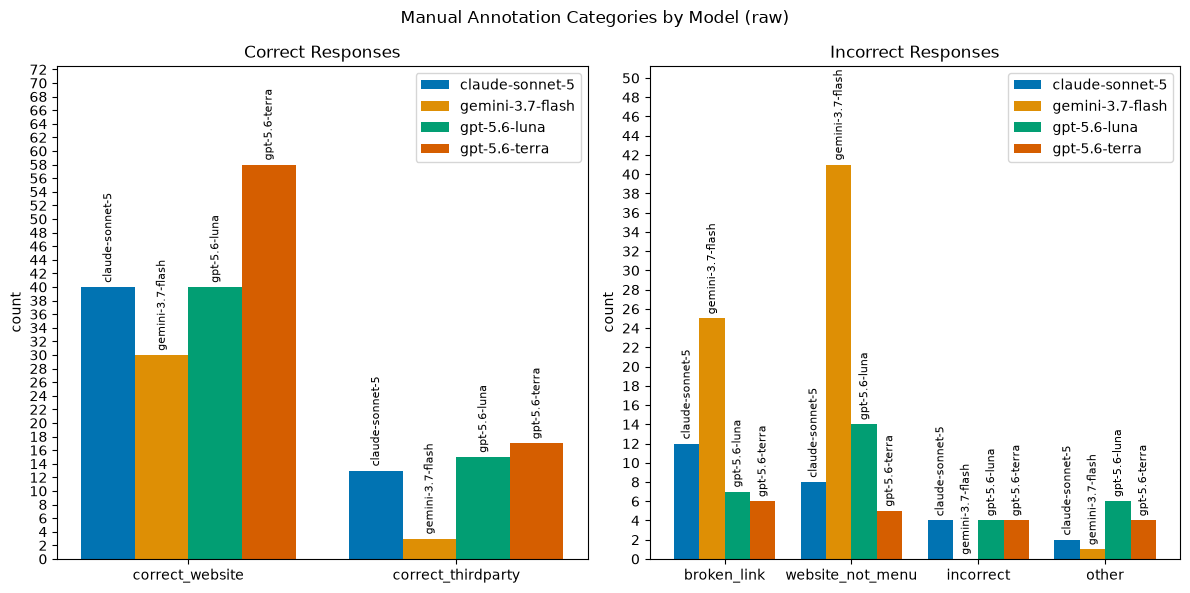

In [45]:
correct_categories = ['correct_website', 'correct_thirdparty']
incorrect_categories = ['broken_link', 'website_not_menu', 'incorrect', 'other']

models_annotated = category_counts_raw.index
n_models = len(models_annotated)
width = 0.8 / n_models
colors = sns.color_palette('colorblind', n_colors=n_models)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, categories, title in zip(axes, [correct_categories, incorrect_categories], ['Correct Responses', 'Incorrect Responses']):
    x = np.arange(len(categories))

    for i, model in enumerate(models_annotated):
        offset = (i - (n_models - 1) / 2) * width
        counts = category_counts_raw.loc[model, categories]
        bars = ax.bar(x + offset, counts.values, width=width, color=colors[i], label=model)
        ax.bar_label(bars, labels=[model] * len(x), rotation=90, padding=3, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel('count')
    ax.yaxis.set_major_locator(MultipleLocator(2))
    ax.set_title(title)
    ax.margins(y=0.25)
    ax.legend(loc='upper right')

fig.suptitle('Manual Annotation Categories by Model (raw)')
plt.tight_layout()
plt.show()

#### Calculate percentile distribution across models

In [46]:
category_pct = round(category_counts_raw.div(category_counts_raw.sum(axis=1), axis=0) * 100, 2)
category_pct

category,correct_website,correct_thirdparty,broken_link,website_not_menu,incorrect,other
model,,,,,,
claude-sonnet-5,50.63,16.46,15.19,10.13,5.06,2.53
gemini-3.7-flash,30.00,3.00,25.00,41.00,0.00,1.00
gpt-5.6-luna,46.51,17.44,8.14,16.28,4.65,6.98
gpt-5.6-terra,61.70,18.09,6.38,5.32,4.26,4.26


In [47]:
cb = sns.color_palette("colorblind")
cb

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

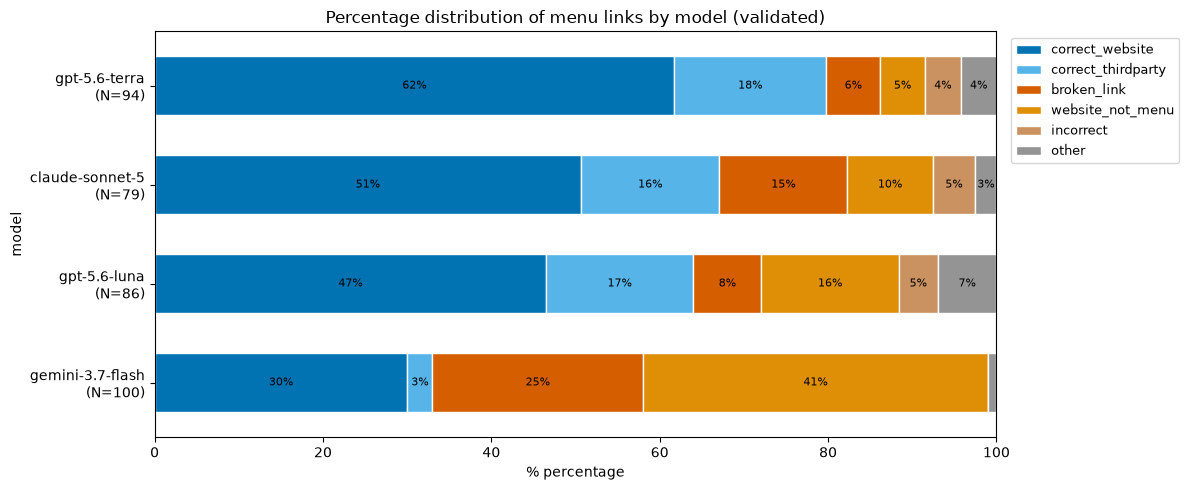

In [48]:
# blues = correct, warm = incorrect, grey = other
category_colors = [cb[0], cb[9], cb[3], cb[1], cb[5], cb[7]]

# ascending, since barh draws the first row at the bottom -> most correct_website on top
plot_df = category_pct.sort_values('correct_website')
n_per_model = category_counts_raw.sum(axis=1)

ax = plot_df.plot(kind='barh', stacked=True, color=category_colors, edgecolor='white', width=0.6, figsize=(12, 5))

for bars in ax.containers:
    ax.bar_label(bars, labels=[f'{v:.0f}%' if v > 2 else '' for v in bars.datavalues], label_type='center', fontsize=8)

ax.set_yticklabels([f'{model}\n(N={n_per_model[model]})' for model in plot_df.index])
ax.set_xlim(0, 100)
ax.set_xlabel('% percentage')
ax.set_ylabel('model')
ax.set_title('Percentage distribution of menu links by model (validated)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

In [49]:
other = annotations[annotations['category'] == 'other']
other = other.sort_values(by=['model'])
other

,id,model,url,category,notes
23,ChIJ0-wVKQNTUkYRq7EvwrzGbBM,claude-sonnet-5,https://wolt.com/en/dnk/copenhagen/restaurant/...,other,permanently closed
178,ChIJB0yyYxxTUkYRKjbWYP1K57M,claude-sonnet-5,https://www.pricelisto.com/menu-prices/its-bur...,other,invalid link to a third party
24,ChIJ0-wVKQNTUkYRq7EvwrzGbBM,gemini-3.7-flash,https://friesbar.dk/,other,permanently closed - redirects to burger websi...
21,ChIJ-ycvCwBTUkYRSwlECtGiROQ,gpt-5.6-luna,https://img1.wsimg.com/blobby/go/ebad81b4-4b96...,other,"outdated menu, menu also found on website: htt..."
69,ChIJ3c3dEJpaUkYR11WNLxCkf7g,gpt-5.6-luna,https://greatsushi-2750.dk/,other,correct thirdparty menu but prices are all 0 -...
173,ChIJAzGKQYpTUkYRLkFWaLyI6Ds,gpt-5.6-luna,https://juliliving.dk/siljangade/,other,not a restaurant - permenantly closed. rental ...
182,ChIJBSbO015SUkYRjHUE46ko9ZE,gpt-5.6-luna,https://www.grospiseri.dk/s/Winter-menu-Lunch-...,other,winter menu
296,ChIJIc6dF7lZUkYRwY3PdNf_dN8,gpt-5.6-luna,https://semeny.no/dk/sted/shawarmahuset,other,not sure what this menu source is
353,ChIJM5GZm8pTUkYRZ2yt6zkNauM,gpt-5.6-luna,https://www.meny.semeny.no/dk/sted/pastalabcop...,other,unsure what this menu link is
19,ChIJ-fk2NRBTUkYRyhj40xrfESA,gpt-5.6-terra,https://starwinelist.com/storage/food_menus/21...,other,"link to unknown image of possibly the menu, bu..."
